In [1]:
import os
os.environ["CUDA_DEVICE_ORDER"]="PCI_BUS_ID"   # see issue #152
os.environ["CUDA_VISIBLE_DEVICES"]="0"

import sys
sys.path.insert(0, "/staging/leuven/stg_00002/lcb/gpartel/software/deepSCENIC")
import os
import torch
import numpy as np
import scanpy as sc
import pandas as pd
import argparse
import json
from skimage import filters
import matplotlib.pyplot as plt
import seaborn as sns

from src.deepSCENIC import deepSCENIC

2025-08-06 14:33:29.782236: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F AVX512_VNNI FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-08-06 14:33:33.630655: I tensorflow/core/util/util.cc:169] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-08-06 14:33:35.505779: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /apps/leuven/rocky8/icelake/2022a/software/libxslt/1.1.34-GCCcore-11.3.0/lib:/apps/leuven/rocky8

In [2]:
torch.cuda.is_available()

False

#### Load deepSCENIC model

In [3]:
# Output dir of deepSCENIC
RES_PATH = '/lustre1/project/stg_00002/lcb/gpartel/projects/deepSCENIC/results/MM_lines/'
parser = argparse.ArgumentParser()
opt = parser.parse_args('')
with open(RES_PATH + "/hyperparma.txt", 'r') as f:
            opt.__dict__.update(json.load(f))

In [4]:
opt.train = False
opt.use_best=False
opt.balance_dars = False
opt.batch_key = None
opt.data_rna_file_test = '/lustre1/project/stg_00002/lcb/gpartel/projects/deepSCENIC/data/MM_lines/raw_exprMat_test.h5ad'
# opt.data_atac_file = '/lustre1/project/stg_00002/lcb/gpartel/projects/deepSCENIC/data/MM_lines/fragment_matrix_train.h5ad'
# opt.data_rna_file = '/lustre1/project/stg_00002/lcb/gpartel/projects/deepSCENIC/data/MM_lines/raw_exprMat_train.h5ad'

In [5]:
opt.bin_acc

False

In [6]:
# Compile model
ds_model = deepSCENIC(opt)
dataloader, TFs_idx, r2g_dist_coo, seq_dataloader, _ = ds_model.init_data()

dir exist
reading data...
data read!
AnnData object with n_obs × n_vars = 936 × 12188
    var: 'n_cells'
    layers: 'log_norm'
AnnData object with n_obs × n_vars = 936 × 281820


### Extract TF2r (TF to region: E1) and r2g (region to gene: E2) matrix

In [7]:
from src.model import VAE
from src.tf2rNet.models import MotifNet, Sei
from enformer_pytorch import Enformer
from tqdm import tqdm
import pickle

ds_model.opt.split_test = False
ds_model.opt.train = False
if opt.use_best==True:
    model_dict_tf2r_func_enc_path = opt.save_name + 'best_model_tf2r_encoder.pth'
    model_dict_tf2r_path = opt.save_name + 'best_model_tf2r.pth'
    vae_model_path = opt.save_name + 'best_model.pth'
else:
    model_dict_tf2r_func_enc_path = opt.save_name + 'model_tf2r_encoder.pth'
    model_dict_tf2r_path = opt.save_name + 'model_tf2r.pth'
    vae_model_path = opt.save_name + 'model.pth'        


if opt.device=='cuda':
    Tensor = torch.cuda.FloatTensor
elif opt.device=='cpu':
    Tensor = torch.FloatTensor

# adj_E1s = []
# for i in range(10):
with torch.no_grad():
    tf2rNet = MotifNet(ds_model.TFs, opt.TF2rNet_bottleneck_size, emb_len=opt.emb_len, dev=opt.device).float().to(opt.device)
    tf2rNet.load_state_dict(torch.load(model_dict_tf2r_path,  map_location=torch.device(opt.device))['model_state_dict'])
    # Initialize Enformer model
    tf2rNet_func_encoder = Enformer.from_pretrained('EleutherAI/enformer-official-rough', target_length=5, dropout_rate = 0).to(opt.device)
    tf2rNet_func_encoder.load_state_dict(torch.load(model_dict_tf2r_func_enc_path,  map_location=torch.device(opt.device))['model_state_dict'])
    # vae = VAE(TFs_idx, r2g_dist_coo, 1, model.opt.n_hidden, dev=model.opt.device).float().to(model.opt.device)
    # vae.load_state_dict(torch.load(model.opt.save_name + 'model.pth',  map_location=torch.device(opt.device))['model_state_dict'])


    # Define the concatenated model with a custom forward method
    class ConcatModel(torch.nn.Module):
        def __init__(self, models):
            super(ConcatModel, self).__init__()
            self.models = torch.nn.ModuleList(models)
    
        def forward(self, seq,):
            for model in self.models:
                if isinstance(model, Enformer):
                    x = model(seq, return_only_embeddings=True)
                elif isinstance(model, MotifNet):                 
                    x = model(emb=x)
                    # x = torch.unsqueeze(x, dim=0)
                else:
                    x = model(seq)
            return x

    
    model = ConcatModel([tf2rNet_func_encoder, tf2rNet]).to(opt.device)   
    model.eval()
    # TF2rNet forward pass
    E1 = []
    for j, (seq, seq_data_batch_idx) in tqdm(enumerate(seq_dataloader, 0)):
        X_E1 = model(seq[0].to(opt.device))
        E1.append(X_E1)
    adj_E1 = torch.cat(E1)

1410it [02:27,  9.57it/s]


In [8]:
E1 = pd.DataFrame(adj_E1.T.detach().cpu().numpy(), columns=dataloader['atac_region_name'], index=np.array(dataloader['rna_gene_name'])[TFs_idx])

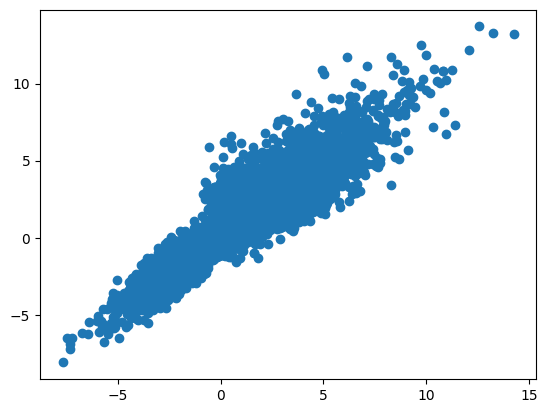

In [9]:
plt.scatter(E1.loc['SOX10'], E1.loc['MITF'])

In [9]:
from scipy.sparse import load_npz

with torch.no_grad():
    vae = VAE(TFs_idx, r2g_dist_coo, 1, ds_model.opt.n_hidden, opt=opt).float()
    vae.load_state_dict(torch.load(vae_model_path,  map_location=torch.device('cpu'))['model_state_dict'])
    print("Best training epoch: ", torch.load(vae_model_path)['epoch'])
with torch.no_grad():
    r2g_dist_coo_test = load_npz('/lustre1/project/stg_00002/lcb/gpartel/projects/deepSCENIC/data/MM_lines/r2gpenalty_test.npz')
    adj_E2_test = torch.load(opt.save_name + '/E2_test.pth')['vae_E2_test']
    r2g_dist_test = torch.sparse_coo_tensor(torch.tensor([r2g_dist_coo_test.row.tolist(), r2g_dist_coo_test.col.tolist()]), torch.tensor(1/r2g_dist_coo_test.data).float(), r2g_dist_coo_test.shape, requires_grad=False).coalesce().float()
    E2_test = torch.sparse_coo_tensor(r2g_dist_test.indices().to(opt.device), adj_E2_test.abs(), r2g_dist_test.shape).to_dense()
    
    r2g_dist = torch.sparse_coo_tensor(torch.tensor([r2g_dist_coo.row.tolist(), r2g_dist_coo.col.tolist()]), torch.tensor(1/r2g_dist_coo.data).float(), r2g_dist_coo.shape, requires_grad=False).coalesce().float()
    E2_train = torch.sparse_coo_tensor(r2g_dist.indices().to(opt.device), vae.adj_E2.abs(), r2g_dist.shape).to_dense()
    
    r2g_dist_coo_train = load_npz('/lustre1/project/stg_00002/lcb/gpartel/projects/deepSCENIC/data/MM_lines/r2gpenalty_train.npz')
    adj_E2_train = torch.load(opt.save_name + '/E2_train.pth')['vae_E2_test']
    r2g_dist_train = torch.sparse_coo_tensor(torch.tensor([r2g_dist_coo_train.row.tolist(), r2g_dist_coo_train.col.tolist()]), torch.tensor(1/r2g_dist_coo_train.data).float(), r2g_dist_coo_train.shape, requires_grad=False).coalesce().float()
    E2_train = torch.sparse_coo_tensor(r2g_dist_train.indices().to(opt.device), adj_E2_train.abs(), r2g_dist_train.shape).to_dense()
    
    

Best training epoch:  232


In [10]:
E2_train = pd.DataFrame(E2_train.cpu().numpy(), columns=sc.read(opt.data_rna_file_train).var_names, index=sc.read(opt.data_atac_file_train).var_names)
E2_test = pd.DataFrame(E2_test.cpu().numpy(), columns=sc.read(opt.data_rna_file_test).var_names, index=sc.read(opt.data_atac_file_test).var_names)

In [11]:
E2_test = E2_test.iloc[:, np.where(E2_test.sum(0)!=0)[0]]
E2_train = E2_train.loc[:, ~E2_train.columns.isin(E2_test)]
E2 = pd.merge(E2_train, E2_test, left_index=True, right_index=True, how='outer')
E2 = E2.fillna(0)
E2 = E2.loc[dataloader['atac_region_name'], dataloader['rna_gene_name']]
# E2=E2_train

In [12]:
# Save matrices
E1.to_pickle(RES_PATH + 'E1.pkl')
E2.to_pickle(RES_PATH + 'E2.pkl') 

In [13]:
from sklearn.metrics.pairwise import cosine_similarity
res = cosine_similarity(E1.values, E1.values)

In [14]:
res = pd.DataFrame(res, columns=E1.index, index=E1.index)

In [15]:
res.loc['MITF', 'SOX10']

0.98511577

In [16]:
res

,ABCF2,ABL1,ACAA1,ACO1,ADARB1,ADNP,ADNP2,AEBP2,AFF4,AGGF1,...,ZSCAN26,ZSCAN29,ZSCAN30,ZSCAN31,ZSCAN32,ZSCAN5A,ZSCAN9,ZSWIM1,ZXDB,ZXDC
ABCF2,1.000170,0.011208,0.368675,0.195535,-0.555805,0.552677,0.526715,0.146967,0.290028,0.057812,...,-0.115810,0.456930,-0.411752,0.311015,-0.052749,-0.531435,-0.416991,-0.261541,-0.128627,0.247972
ABL1,0.011208,1.000164,-0.195262,-0.022384,0.082260,0.255333,0.384294,0.286603,-0.075320,0.064041,...,0.212383,-0.147708,-0.656224,-0.040715,0.061909,-0.070650,-0.163408,0.067986,-0.441615,-0.348719
ACAA1,0.368675,-0.195262,1.000184,0.588803,-0.331180,0.714275,0.010300,-0.142109,-0.158055,-0.078305,...,-0.095190,0.069246,0.194842,0.740350,0.294183,-0.320379,-0.001932,-0.086626,0.188271,-0.013930
ACO1,0.195535,-0.022384,0.588803,1.000256,-0.586235,0.593915,0.076958,-0.195753,-0.504142,-0.041960,...,-0.153934,-0.271499,0.241371,0.695788,0.154708,-0.263865,-0.187589,-0.335790,0.342194,-0.299193
ADARB1,-0.555805,0.082260,-0.331180,-0.586235,1.000304,-0.523676,-0.662318,-0.218100,0.419515,-0.039952,...,-0.019225,-0.067895,0.223708,-0.333903,0.243123,0.134369,0.736703,0.714758,-0.063738,-0.046757
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ZSCAN5A,-0.531435,-0.070650,-0.320379,-0.263865,0.134369,-0.461735,0.013015,-0.212696,-0.460441,-0.361358,...,-0.162130,-0.005551,-0.005143,-0.403185,-0.016710,1.000108,-0.155856,-0.361483,0.067944,0.313121
ZSCAN9,-0.416991,-0.163408,-0.001932,-0.187589,0.736703,-0.225047,-0.879687,-0.177131,0.428218,0.113621,...,0.038447,-0.092530,0.626122,0.133553,0.223244,-0.155856,1.000295,0.849184,-0.107937,-0.064464
ZSWIM1,-0.261541,0.067986,-0.086626,-0.335790,0.714758,-0.131574,-0.663727,0.097117,0.654158,0.284453,...,0.260312,-0.155520,0.321002,0.074390,0.128243,-0.361483,0.849184,1.000234,-0.293886,-0.218256
ZXDB,-0.128627,-0.441615,0.188271,0.342194,-0.063738,-0.257566,-0.180564,-0.437375,-0.290702,-0.138391,...,-0.252786,-0.157809,0.357910,-0.104965,0.166255,0.067944,-0.107937,-0.293886,1.000179,-0.152065


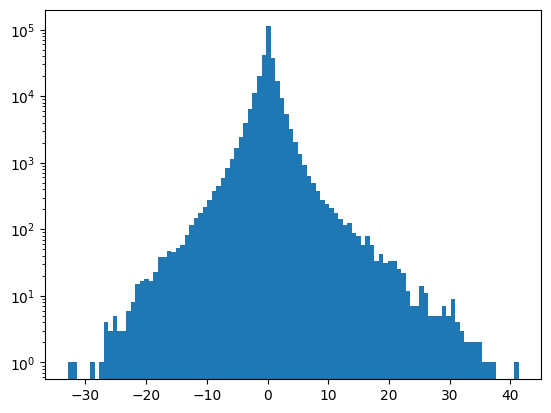

In [17]:
# Plot distribution of enhancer activities
tf = 'SOX10'
plt.hist(E1.loc[tf, :], bins=100);
plt.yscale('log')

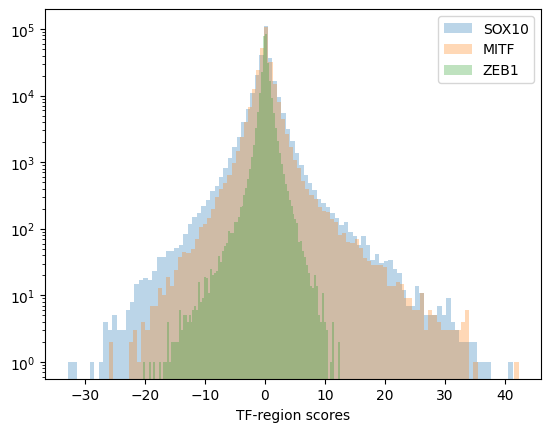

In [18]:
# Plot distribution of enhancer activities
tf = 'SOX10'
plt.hist(E1.loc[tf, :], bins=100, alpha=0.3, label=tf);
tf = 'MITF'
plt.hist(E1.loc[tf, :], bins=100, alpha=0.3, label=tf);
tf = 'ZEB1'
plt.hist(E1.loc[tf, :], bins=100, alpha=0.3, label=tf);
plt.yscale('log')
plt.xlabel('TF-region scores')
plt.legend()

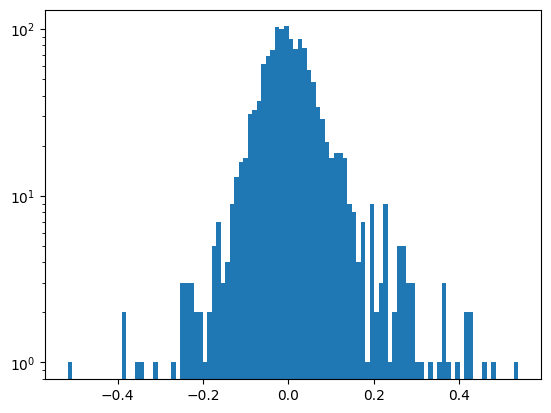

In [19]:
# Plot distribution of enhancer activities
plt.hist(E1.loc[:, E1.columns[0]], bins=100);
plt.yscale('log')

Text(0, 0.5, 'MITF')

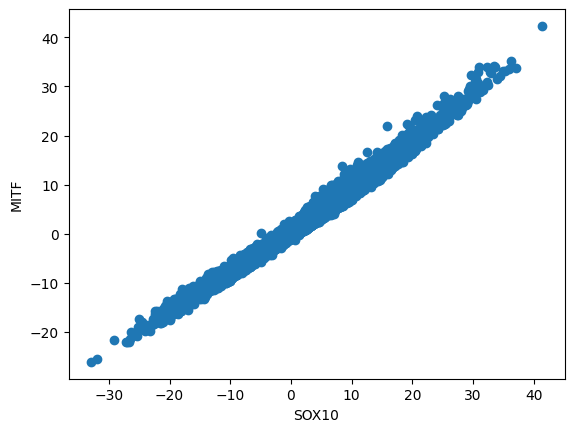

In [20]:
plt.scatter(E1.loc['SOX10',:], E1.loc['MITF',:])
plt.xlabel('SOX10')
plt.ylabel('MITF')

Text(0, 0.5, 'TFAP2A')

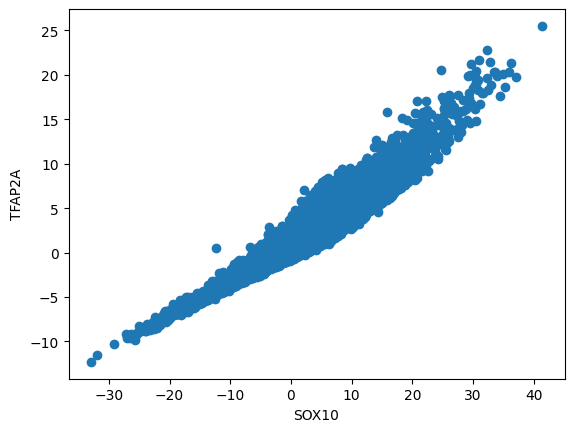

In [21]:
plt.scatter(E1.loc['SOX10',:], E1.loc['TFAP2A',:])
plt.xlabel('SOX10')
plt.ylabel('TFAP2A')

In [22]:
import torch.nn.functional as F

def cosine_similarity(mtx):
    # Transpose the matrix to have columns as vectors
    matrix_transposed = mtx.t()

    # Normalize the columns to unit vectors (optional but recommended)
    matrix_transposed_normalized = F.normalize(matrix_transposed, p=2, dim=1)

    # Compute cosine similarity
    cosine_sim_matrix = torch.mm(matrix_transposed_normalized, matrix_transposed_normalized.t())
    cosine_sim_matrix = cosine_sim_matrix.fill_diagonal_(0)
    # cosine_sim_matrix[cosine_sim_matrix<0]=0
    print(cosine_sim_matrix.shape)
    return torch.mean(cosine_sim_matrix.pow(2).mean(1))# * mtx.abs().mean(0))


In [23]:
res = cosine_similarity(adj_E1) #+ adj_E1.abs().mean(1).mean()

torch.Size([1386, 1386])


In [24]:
res

tensor(0.1270, device='cuda:0')

In [25]:
adj_E1.abs().mean(0).shape

torch.Size([1386])

In [26]:
adj_E1.abs().mean(1).mean()

tensor(0.1794, device='cuda:0')

In [27]:
g='IRF4'
g_dist = [int(x.split(':')[1].split('-')[0]) - 391752 for x in E2.loc[:, g][E2.loc[:, g]!=0].sort_values().index]

In [28]:
E2.loc[:, g][E2.loc[:, g]!=0].sort_values()

chr6:1391867-1392367    2.888633e-08
chr6:659825-660325      4.188164e-08
chr6:1132313-1132813    6.067160e-08
chr6:1364771-1365271    7.461865e-08
chr6:147571-148071      7.844616e-08
                            ...     
chr6:397016-397516      1.193492e-02
chr6:461501-462001      3.601507e-02
chr6:450374-450874      3.602150e-02
chr6:456790-457290      6.288492e-02
chr6:398830-399330      1.084446e-01
Name: IRF4, Length: 148, dtype: float32

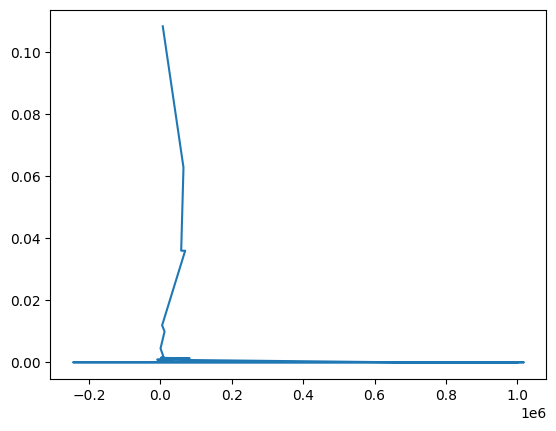

In [29]:
plt.plot(g_dist, E2.loc[:, g][E2.loc[:, g]!=0].sort_values().values)

# Extract TF, enhancer activities and other latent representations

In [30]:
with torch.no_grad():
    E2 = torch.tensor(pd.read_pickle(RES_PATH + 'E2.pkl').values).to(opt.device)
    E1 = torch.tensor(pd.read_pickle(RES_PATH + 'E1.pkl').values).to(opt.device)
ds_model.to_latent(adj_E1=E1.T, adj_E2=E2)

reading data...
data read!
AnnData object with n_obs × n_vars = 936 × 12188
    var: 'n_cells'
    layers: 'log_norm'
AnnData object with n_obs × n_vars = 936 × 281820
loaded weights for TF2rNet
VAE forward...


100%|██████████| 59/59 [00:01<00:00, 29.59batch/s]


In [7]:
# Read gene expression data and cell annotations
DATA_PATH = '/staging/leuven/stg_00002/lcb/gpartel/projects/deepSCENIC/data/MM_lines/'

ad = sc.read(opt.data_rna_file)
cells_metadata = pd.read_csv(DATA_PATH + '/cells_metadata.csv', index_col=0)
ad.obs[cells_metadata.columns] = cells_metadata.loc[ad.obs.index,:].values

# Load latent representations
ad.obsm['z_rna'] = np.load(opt.save_name + 'z_rna.npy', allow_pickle=True) # Latent target gene expression
ad.obsm['y_rna'] = np.load(opt.save_name + 'y_rna.npy', allow_pickle=True) # Predicted target gene expression\
ad.obsm['y_atac'] = np.load(opt.save_name + 'y_atac.npy', allow_pickle=True) # Predicted chromatin accessibility
ad.obsm['enh_act'] = np.load(opt.save_name + 'z_rna_atac.npy', allow_pickle=True) # Predicted enhancer activity
ad.obsm['tf_act'] = np.load(opt.save_name + 'z_tf_reg.npy', allow_pickle=True) # Predicted TF activity

ad

AnnData object with n_obs × n_vars = 936 × 12188
    obs: 'MMline', 'lineState'
    var: 'n_cells'
    obsm: 'z_rna', 'y_rna', 'y_atac', 'enh_act', 'tf_act'
    layers: 'log_norm'

         Falling back to preprocessing with `sc.pp.pca` and default params.


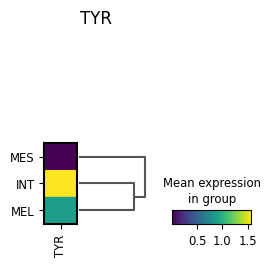

In [8]:
sc.pl.matrixplot(ad, 'TYR', groupby='lineState', dendrogram=True, title='TYR')

In [9]:
ad_yrna = ad.copy()

In [10]:
ad_yrna.X = ad_yrna.obsm['y_rna']

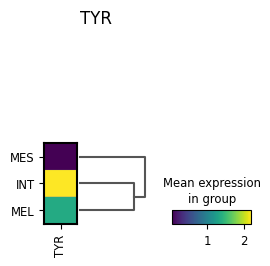

In [11]:
sc.pl.matrixplot(ad_yrna, 'TYR', groupby='lineState', dendrogram=True, title='TYR')

         Falling back to preprocessing with `sc.pp.pca` and default params.


/data/leuven/340/vsc34097/software/conda/envs/DeepSEM/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


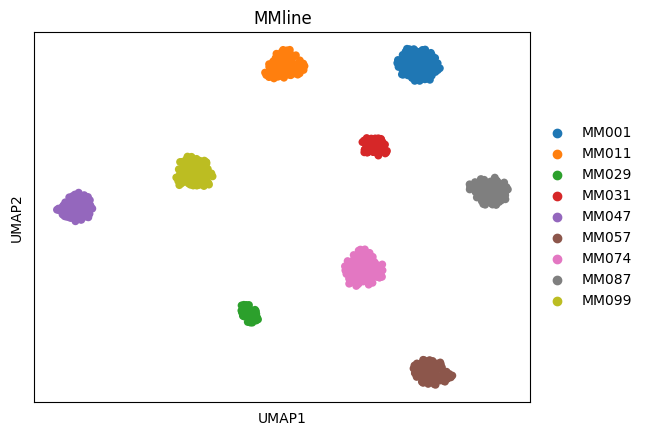

In [8]:
# UMAP of input TF expression
ad_tf = ad[:, TFs_idx].copy()
sc.pp.neighbors(ad_tf, n_pcs=50)
sc.tl.umap(ad_tf)
sc.pl.umap(ad_tf, color=['MMline'])

         Falling back to preprocessing with `sc.pp.pca` and default params.


/data/leuven/340/vsc34097/software/conda/envs/DeepSEM/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/data/leuven/340/vsc34097/software/conda/envs/DeepSEM/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


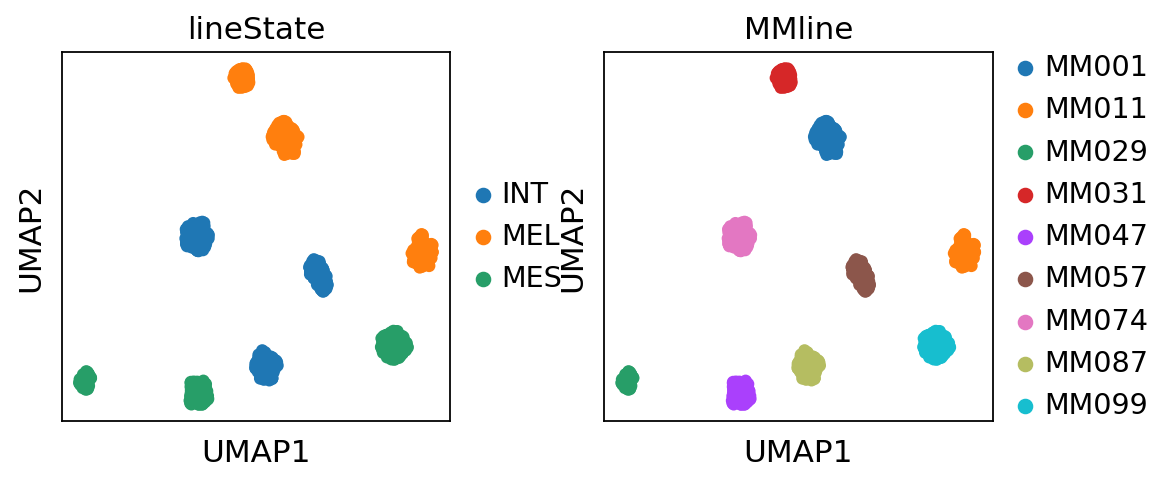

In [8]:
# UMAP of input TF expression
sc.set_figure_params(figsize=(3,3))
sc.pp.neighbors(ad, n_pcs=50)
sc.tl.umap(ad)
sc.pl.umap(ad, color=['lineState', 'MMline'])

/data/leuven/340/vsc34097/software/conda/envs/DeepSEM/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


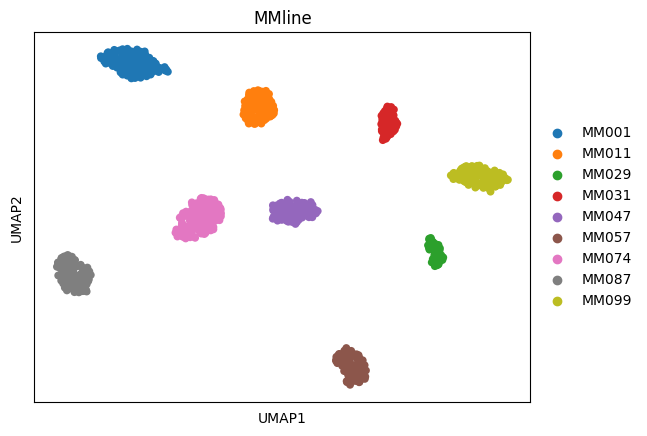

In [26]:
# UMAP of input target gene expression
sc.pp.neighbors(ad, use_rep='y_rna', n_pcs=50)
sc.tl.umap(ad)
sc.pl.umap(ad, color=['MMline'])
ad.obsm['X_yrna_umap'] = ad.obsm['X_umap']

/data/leuven/340/vsc34097/software/conda/envs/DeepSEM/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


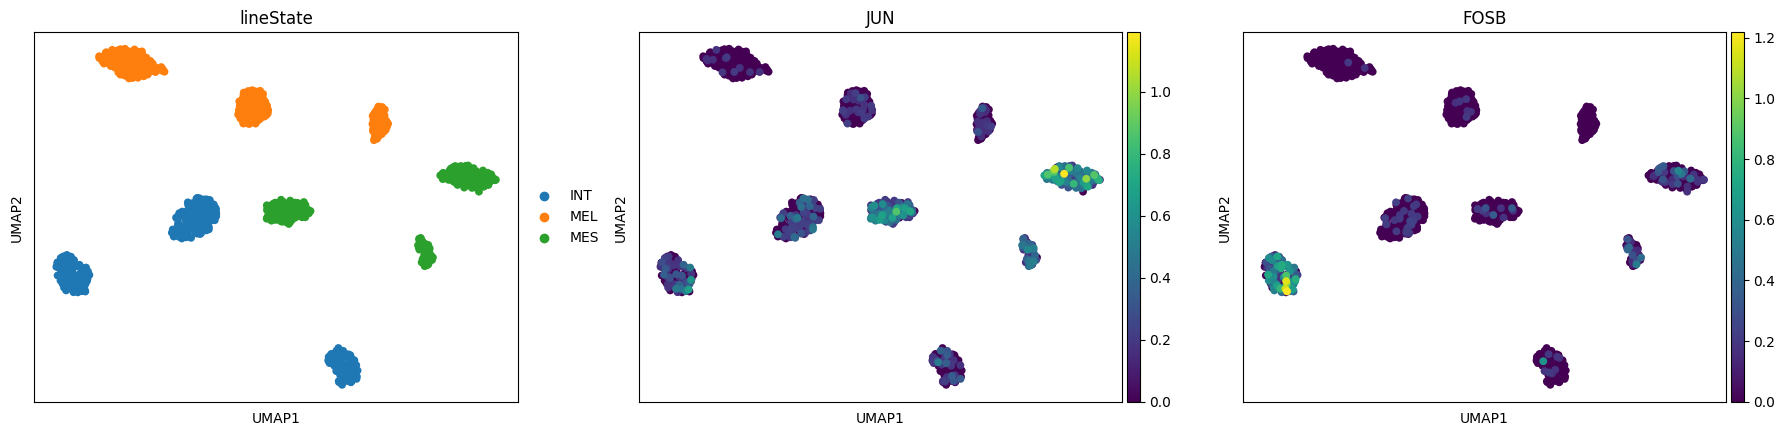

In [27]:
# UMAP of input target gene expression
sc.pp.neighbors(ad, use_rep='y_rna', n_pcs=50)
sc.tl.umap(ad)
sc.pl.umap(ad, color=['lineState', 'JUN', 'FOSB'])
ad.obsm['X_yrna_umap'] = ad.obsm['X_umap']

/data/leuven/340/vsc34097/software/conda/envs/DeepSEM/lib/python3.8/site-packages/sklearn/manifold/_spectral_embedding.py:260: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/data/leuven/340/vsc34097/software/conda/envs/DeepSEM/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/data/leuven/340/vsc34097/software/conda/envs/DeepSEM/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


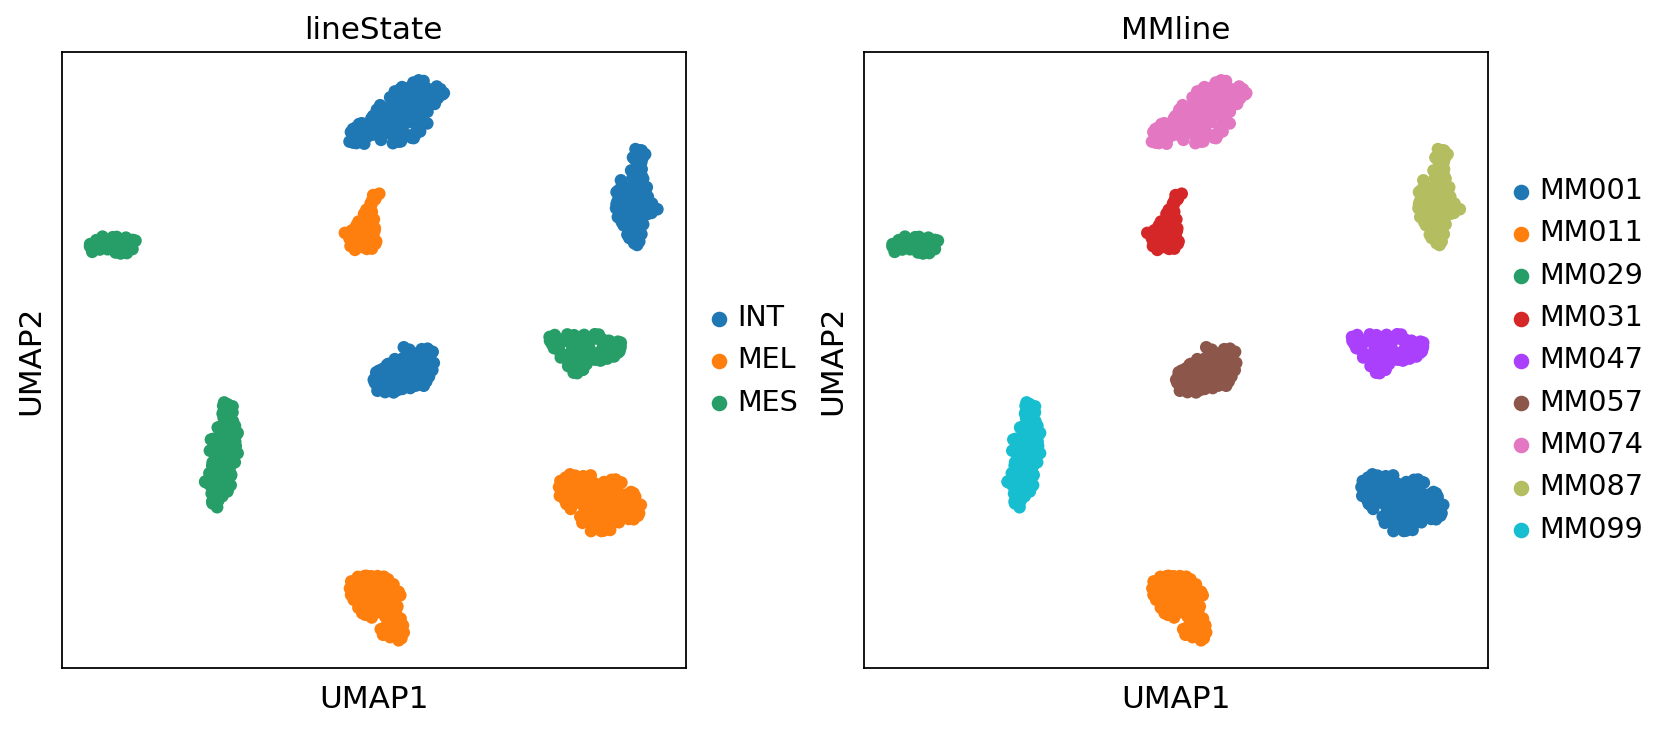

In [9]:
# UMAP of enhancer activity
sc.set_figure_params(figsize=(5,5))
sc.pp.neighbors(ad, use_rep='enh_act', key_added="enh_act")
sc.tl.umap(ad,  neighbors_key='enh_act')
sc.pl.umap(ad, color=['lineState', 'MMline'])
ad.obsm['X_enh_act_umap'] = ad.obsm['X_umap']

### Building eGRN 

Select eRegulons

In [9]:
# Load tfs-regions and regions-genes interaction matrices
E1 = pd.read_pickle(RES_PATH + 'E1.pkl')
# E2 = pd.read_pickle(RES_PATH + 'E2.pkl')

In [37]:
Wrna = E1 @ E2
Wrna

,ABCF2,ABL1,ACAA1,ACO1,ADARB1,ADNP,ADNP2,AEBP2,AFF4,AGGF1,...,ZC3H18,ZDHHC1,ZDHHC7,ZG16B,ZKSCAN2,ZNF469,ZNF747,ZNF821,ZNF843,ZNRF1
ABCF2,0.100592,-0.005113,0.001955,0.028937,-1.999417e-06,0.025874,0.011234,-0.003995,0.012907,0.019484,...,-0.004465,-3.280686e-06,0.004405,0.000007,0.000005,-0.000112,-0.000002,-3.021173e-06,-0.000009,0.013317
ABL1,0.017247,0.029776,-0.024566,0.008636,-5.786409e-06,0.037251,0.031972,0.016128,-0.012506,-0.007067,...,-0.047811,-1.706621e-05,0.015533,-0.000015,0.000003,-0.000255,-0.000017,-1.613636e-05,-0.000024,-0.004536
ACAA1,0.016922,-0.009184,0.003083,0.024409,1.084876e-06,0.008476,-0.009853,-0.016507,-0.015641,-0.002302,...,0.017662,-1.241347e-05,-0.004392,-0.000017,-0.000002,0.000097,-0.000003,-1.273353e-05,-0.000002,0.000575
ACO1,0.020378,0.002020,-0.006120,0.143067,2.606022e-05,0.108465,0.029043,-0.012051,0.020849,0.016613,...,0.072072,8.806701e-06,0.014891,0.000035,0.000025,0.000406,0.000014,3.657460e-07,0.000019,0.060716
ADARB1,-0.034734,-0.007714,0.008470,0.010706,-9.937851e-06,-0.013809,-0.036572,-0.006941,0.004652,-0.007025,...,-0.032168,1.241210e-05,-0.026304,-0.000004,-0.000003,0.000189,0.000001,8.259503e-06,0.000012,-0.029230
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ZSCAN5A,-0.025598,-0.009472,-0.016272,-0.040761,-3.188148e-05,-0.029067,-0.009128,-0.017196,-0.019894,-0.013406,...,-0.038139,-4.537079e-05,-0.025354,-0.000040,-0.000005,-0.000354,-0.000026,-1.909555e-05,-0.000022,-0.013316
ZSCAN9,-0.010364,-0.007664,0.002495,0.003351,-3.173616e-07,-0.008193,-0.007810,-0.008226,0.000197,0.011435,...,0.004520,-1.278326e-06,-0.008008,-0.000010,-0.000007,-0.000018,-0.000009,1.102437e-06,-0.000002,-0.005875
ZSWIM1,0.013712,0.009743,0.014860,0.013639,1.491140e-05,0.010498,-0.015248,-0.001263,0.008381,0.020931,...,0.043241,-4.076073e-07,-0.000940,-0.000004,-0.000002,0.000038,-0.000007,2.158762e-07,0.000008,-0.008817
ZXDB,-0.014048,-0.022215,0.001335,-0.003462,-1.778704e-05,-0.033774,-0.032985,-0.028946,-0.007594,-0.001420,...,-0.020633,-2.654396e-05,-0.020270,-0.000027,0.000002,-0.000120,-0.000004,-8.314140e-06,-0.000002,0.001202


In [38]:
E1.loc['TCF4', E2.loc[:, 'IRF7'].sort_values(ascending=False)[:10].index]

chr11:644722-645222      0.063179
chr11:608135-608635      0.099031
chr11:612043-612543      0.136354
chr11:614334-614834     -0.042080
chr11:772802-773302     -1.388983
chr11:1397106-1397606   -1.689426
chr11:606205-606705      4.077988
chr11:690920-691420     -0.131956
chr11:623876-624376      0.354208
chr11:374008-374508     -6.309593
Name: TCF4, dtype: float32

In [39]:
Wrna.loc[:, 'NLRC5'].sort_values()

ZNF597    -0.000087
GLI3      -0.000076
ZNF107    -0.000072
TIGD6     -0.000071
ZNF665    -0.000070
             ...   
ZSCAN23    0.000092
ZNF45      0.000094
E2F8       0.000099
ESRRG      0.000118
ZNF25      0.000124
Name: NLRC5, Length: 1386, dtype: float32

In [40]:
Wrna.loc['TCF4', 'NLRC5']

2.7763119e-05

In [41]:
Wrna.loc['TCF4', 'IRF7']

0.00019732736

In [42]:
Wrna.loc['TCF4', 'MITF']

-0.12693721

In [11]:
# Building AnnData objects containing enhancer activity and TFs activity profiles for each cell
ad_enahancer = sc.AnnData(np.load(opt.save_name + 'z_rna_atac.npy', allow_pickle=True), obs=ad.obs)
ad_enahancer.var_names = sc.read(opt.data_atac_file).var_names

ad_tf = sc.AnnData(np.load(opt.save_name + 'z_tf_reg.npy', allow_pickle=True), obs=ad.obs)
ad_tf.var_names = sc.read(opt.data_rna_file).var_names[TFs_idx]

In [44]:
line = 'K562'
# E2 = pd.read_pickle(RES_PATH + 'E2.pkl')
enh_act = ad_enahancer[ad_enahancer.obs.MMline=='MM001'].X.copy()
ct_E2 = enh_act.mean(0)[:,None]  * E2

In [45]:
# ct_E2.loc[:, g][ct_E2.loc[:, g]!=0].abs().mean()

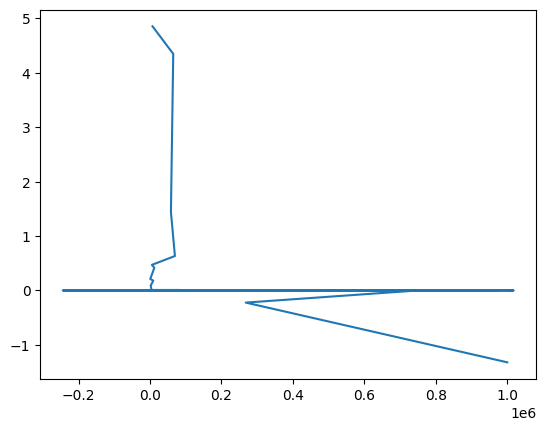

In [46]:
plt.plot(g_dist, ct_E2.loc[:, g][ct_E2.loc[:, g]!=0].sort_values().values)

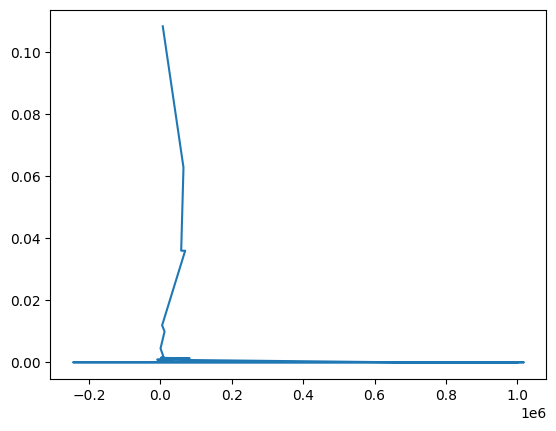

In [47]:
plt.plot(g_dist, E2.loc[:, g][E2.loc[:, g]!=0].sort_values().values)

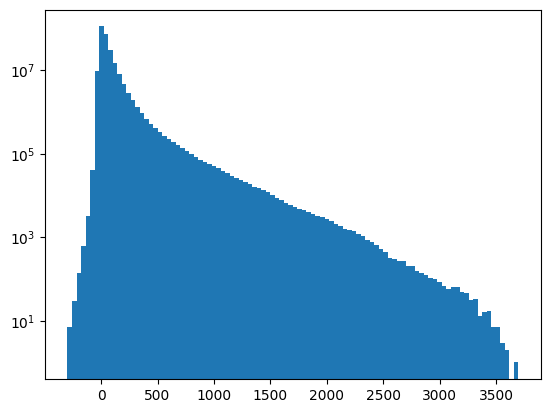

In [48]:
# Plot distribution of enhancer activities
plt.hist(ad_enahancer.X[ad_enahancer.X!=0], bins=100);
plt.yscale('log')

In [13]:
# Building dataframe of enhancer activity profiles per cell-type
df_enancher_activity =[]
for line in ad.obs.MMline.unique():
    df_enancher_activity.append(ad_enahancer[ad_enahancer.obs.MMline==line].to_df().mean(0))
df_enancher_activity = pd.concat(df_enancher_activity, axis=1, keys=ad.obs.MMline.unique())

In [14]:
# Threshold enhancer activity profiles per cell-type and compute TFs activity average profiles
df_tf_activity =[]
active_enhancers_l = []
for line in ad.obs.MMline.unique():
    # Thresholding
    active_enhancers = df_enancher_activity.loc[:, line].abs()
    th = filters.threshold_otsu(active_enhancers.values)
    active_enhancers = active_enhancers[active_enhancers>th]
    
    active_enhancers_l.append(active_enhancers.index.to_list())
    df_tf_activity.append((ad_tf[ad_tf.obs.MMline==line, :].X.mean(0)[:,None] * E1.loc[:, active_enhancers.index]).abs().mean(1)) # TFs activity average profiles
    
df_tf_activity = pd.concat(df_tf_activity, axis=1, keys=ad.obs.MMline.unique())    

In [16]:
# Threshold TFs activity profiles and extract key TFs per cell-type
TFs = []
for line in ad.obs.MMline.unique():
    df_line = df_tf_activity.loc[:,line].abs()
    th = filters.threshold_otsu(df_line.values)
    TFs.extend(df_line[df_line > th].index.to_list())

# Subset TF-region interaction matrix to key TFs
E1_sub = E1.loc[list(set(TFs)), :]

In [52]:
# Build eGRN
from joblib import Parallel, delayed
from tqdm import tqdm
from skimage import filters

r2g_th=0
def tf_df(E1, E2, tf):
    TFs, regions, target_genes, tf2r_scores, r2g_scores, tf2g_scores = [], [], [], [], [], []

    E1_tf = E1.loc[tf,:][E1.abs().loc[tf,:]>0].abs()
    if E1_tf.shape[0]>0:
        tf2r_th = filters.threshold_otsu(E1_tf.values) # Threshold TF-region interaction scores per TF
        regs = E1.loc[tf,:][E1.abs().loc[tf,:] > tf2r_th].index
        for r in regs:
            E2_r = E2.loc[r, :][E2.loc[r, :]>0]
            if E2_r.shape[0]>0:
                # r2g_th = filters.threshold_otsu(E2_r.values)
                targets = E2.loc[r, :][E2.loc[r, :] > r2g_th].index
                for g in targets:            
                    TFs.append(tf)
                    regions.append(r)
                    target_genes.append(g)
                    tf2r_scores.append(E1.loc[tf,r])
                    tf2g_scores.append(E1.loc[tf,r]*E2.loc[r,g])
                    r2g_scores.append(E2.loc[r,g])

    return TFs, regions, target_genes, tf2r_scores, tf2g_scores, r2g_scores

res = Parallel(n_jobs=32)(delayed(tf_df)(E1_sub, E2, tf) for tf in tqdm(E1_sub.index))

TFs, regions, target_genes, tf2r_scores, tf2g_scores, r2g_scores = [], [], [], [], [], []
for i in tqdm(range(len(res))):
    TFs.extend(res[i][0])
    regions.extend(res[i][1])
    target_genes.extend(res[i][2])
    tf2r_scores.extend(res[i][3])
    tf2g_scores.extend(res[i][4])
    r2g_scores.extend(res[i][5])

df_deepSCENIC_grn = pd.DataFrame({'TF':TFs, 'region':regions, 'gene':target_genes, 'tf2r_score':tf2r_scores, 'tf2g_score':tf2g_scores , 'r2g_score':r2g_scores})
df_deepSCENIC_grn.to_pickle(RES_PATH + '/df_deepSCENIC_grn.pkl')
df_deepSCENIC_grn    

100%|██████████| 206/206 [00:01<00:00, 106.64it/s]


,TF,region,gene,tf2r_score,tf2g_score,r2g_score
0,NCBP2,chr10:100751025-100751525,ABCC2,1.791984,1.413913e-05,7.890212e-06
1,NCBP2,chr10:100751025-100751525,BLOC1S2,1.791984,7.324967e-06,4.087629e-06
2,NCBP2,chr10:100751025-100751525,BTRC,1.791984,7.906928e-06,4.412387e-06
3,NCBP2,chr10:100751025-100751525,CHUK,1.791984,5.352200e-06,2.986745e-06
4,NCBP2,chr10:100751025-100751525,CPN1,1.791984,4.447335e-02,2.481794e-02
...,...,...,...,...,...,...
38056153,SREBF2,chr16:9966719-9967219,DEXI,-2.348854,-4.475175e-06,1.905259e-06
38056154,SREBF2,chr16:9966719-9967219,EMP2,-2.348854,-4.980701e-07,2.120481e-07
38056155,SREBF2,chr16:9966719-9967219,NUBP1,-2.348854,-5.238144e-06,2.230085e-06
38056156,SREBF2,chr16:9966719-9967219,TEKT5,-2.348854,-1.549989e-08,6.598917e-09


In [53]:
df_deepSCENIC_grn

,TF,region,gene,tf2r_score,tf2g_score,r2g_score
0,NCBP2,chr10:100751025-100751525,ABCC2,1.791984,1.413913e-05,7.890212e-06
1,NCBP2,chr10:100751025-100751525,BLOC1S2,1.791984,7.324967e-06,4.087629e-06
2,NCBP2,chr10:100751025-100751525,BTRC,1.791984,7.906928e-06,4.412387e-06
3,NCBP2,chr10:100751025-100751525,CHUK,1.791984,5.352200e-06,2.986745e-06
4,NCBP2,chr10:100751025-100751525,CPN1,1.791984,4.447335e-02,2.481794e-02
...,...,...,...,...,...,...
38056153,SREBF2,chr16:9966719-9967219,DEXI,-2.348854,-4.475175e-06,1.905259e-06
38056154,SREBF2,chr16:9966719-9967219,EMP2,-2.348854,-4.980701e-07,2.120481e-07
38056155,SREBF2,chr16:9966719-9967219,NUBP1,-2.348854,-5.238144e-06,2.230085e-06
38056156,SREBF2,chr16:9966719-9967219,TEKT5,-2.348854,-1.549989e-08,6.598917e-09


### Extract differentially active enhancers between cell-type

In [12]:
# ad_enahancer_act = ad_enahancer.copy() # Extract positive enhancers
# ad_enahancer_act.X[ad_enahancer_act.X < 0]=0

# ad_enahancer_rep = ad_enahancer.copy() # Extract negative enhancers
# ad_enahancer_rep.X[ad_enahancer_rep.X > 0]=0
# ad_enahancer_rep.X = np.abs(ad_enahancer_rep.X)

# # Compute differential analysis between cell-types
# sc.tl.rank_genes_groups(ad_enahancer_act, 'ACC_Cell_type', method='wilcoxon')
sc.tl.rank_genes_groups(ad_enahancer, 'lineState', method='wilcoxon')

/data/leuven/340/vsc34097/software/conda/envs/DeepSEM/lib/python3.8/site-packages/scanpy/tools/_rank_genes_groups.py:417: RuntimeWarning: overflow encountered in expm1
  foldchanges = (self.expm1_func(mean_group) + 1e-9) / (
/data/leuven/340/vsc34097/software/conda/envs/DeepSEM/lib/python3.8/site-packages/scanpy/tools/_rank_genes_groups.py:418: RuntimeWarning: overflow encountered in expm1
  self.expm1_func(mean_rest) + 1e-9
/data/leuven/340/vsc34097/software/conda/envs/DeepSEM/lib/python3.8/site-packages/scanpy/tools/_rank_genes_groups.py:417: RuntimeWarning: invalid value encountered in divide
  foldchanges = (self.expm1_func(mean_group) + 1e-9) / (
/data/leuven/340/vsc34097/software/conda/envs/DeepSEM/lib/python3.8/site-packages/scanpy/tools/_rank_genes_groups.py:420: RuntimeWarning: divide by zero encountered in log2
  self.stats[group_name, 'logfoldchanges'] = np.log2(
/data/leuven/340/vsc34097/software/conda/envs/DeepSEM/lib/python3.8/site-packages/scanpy/tools/_rank_genes_groups

In [13]:
# Differntially positve enhancers
DE_enahncer = pd.DataFrame(ad_enahancer.uns['rank_genes_groups']['names'])
DE_enahncer.index = ad_enahancer.var_names
DE_enahncer

,INT,MEL,MES
chr10:100004862-100005362,chr15:99185682-99186182,chr6:100328472-100328972,chr12:117261219-117261719
chr10:100005406-100005906,chrX:120647050-120647550,chr1:241533719-241534219,chr6:4413040-4413540
chr10:100008095-100008595,chr11:43491674-43492174,chr4:76383994-76384494,chr6:44161295-44161795
chr10:100019819-100020319,chr15:66981789-66982289,chr5:7668106-7668606,chr6:44161914-44162414
chr10:100021442-100021942,chr6:37323376-37323876,chr2:237596410-237596910,chr6:44179085-44179585
...,...,...,...
chr16:9931844-9932344,chr2:23541801-23542301,chr5:125891271-125891771,chr12:2734725-2735225
chr16:9950585-9951085,chr6:5905693-5906193,chr5:127801942-127802442,chr2:56972296-56972796
chr16:9966719-9967219,chr14:84826856-84827356,chr5:130532587-130533087,chr2:57045046-57045546
chr16:9973-10473,chr6:106261751-106262251,chr5:13108110-13108610,chr2:57205162-57205662


In [14]:
# # Differntially negative enhancers
# DE_enahncer_rep = pd.DataFrame(ad_enahancer_rep.uns['rank_genes_groups']['names'])
# DE_enahncer_rep.index = ad_enahancer_rep.var_names
# DE_enahncer_rep

In [15]:
n_enhancers = 1000
markers = []
for line in ad.obs.lineState.unique():
    # markers.append(df_enancher_activity.loc[:,line].sort_values(ascending=False)[:n_enhancers].index.values)
    markers.append(DE_enahncer.loc[:,line][:n_enhancers].values)

### Extract keys TFs per cell-type

1. Most active TFs in differentially active enhancers

In [16]:
d = dict(ad_tf.obs.drop_duplicates('MMline').values)

In [81]:
# Extract TF activities on top DA positive enhancers per cell-type
# n_enhancers = 1000
df_tf_activity =[]
for line in ad.obs.MMline.unique():
    df_tf_activity.append((ad_tf[ad_tf.obs.MMline==line, :].X.mean(0)[:,None] * E1.loc[:, DE_enahncer.loc[:, d[line]][:n_enhancers]]).mean(1))

df_tf_activity = pd.concat(df_tf_activity, axis=1, keys=ad.obs.MMline.unique())    

In [82]:
# Extract top activators per cell-type
n_TFs = 10
markers = []
markers_MES = []
markers_MEL = []
for line in ad.obs.MMline.unique():
    markers.append(df_tf_activity.loc[:,line].abs().sort_values(ascending=False)[:n_TFs].index.values)
    if line in ['MM029', 'MM047', 'MM099']:
        markers_MES.append(df_tf_activity.loc[:,line].abs().sort_values(ascending=False)[:n_TFs].index.values)
    if line in ['MM001', 'MM011', 'MM031']:
        markers_MEL.append(df_tf_activity.loc[:,line].abs().sort_values(ascending=False)[:n_TFs].index.values)

In [46]:
MMline_col_d = {'MM001':'#005F73',
                'MM011':'#0A9396',
                'MM031':'#94D2BD',
                'MM087':'#E9D8A6',
                'MM074':'#EE9B00',
                'MM057':'#CA6702',
                'MM029':'#BB3E03',
                'MM047':'#AE2012',
                'MM099':'#9B2226'
               }
ad.obs.MMline = ad.obs.MMline.cat.reorder_categories(list(MMline_col_d.keys()), ordered=True)
ad.uns['MMline_colors'] = ad.obs.MMline.cat.categories.map(MMline_col_d)

lineState_col_d = {'MEL':'#106974',
                'INT':'#E19E38',
                'MES':'#AC2A14',
               }
ad.obs.lineState = ad.obs.lineState.cat.reorder_categories(list(lineState_col_d.keys()), ordered=True)
ad.uns['lineState_colors'] = ad.obs.lineState.cat.categories.map(lineState_col_d)

In [47]:
markers = list(set(np.concatenate(markers)))
# markers = markers + ['ZEB1', 'FOSL1', 'JUN', 'IRF1']

In [48]:
lines_order = ['MM001', 'MM011', 'MM031', 'MM087', 'MM074', 'MM057', 'MM029', 'MM047', 'MM099']
d_col_state = dict(zip(ad.obs.lineState.cat.categories, ad.uns['lineState_colors']))
d_col_line = dict(zip(ad.obs.MMline.cat.categories, ad.uns['MMline_colors']))
df_tf_activity = df_tf_activity.loc[markers, lines_order].T #+ ['TCF4'], lines_order].T

In [49]:
d_col_line

{'MM001': '#005F73',
 'MM011': '#0A9396',
 'MM031': '#94D2BD',
 'MM087': '#E9D8A6',
 'MM074': '#EE9B00',
 'MM057': '#CA6702',
 'MM029': '#BB3E03',
 'MM047': '#AE2012',
 'MM099': '#9B2226'}

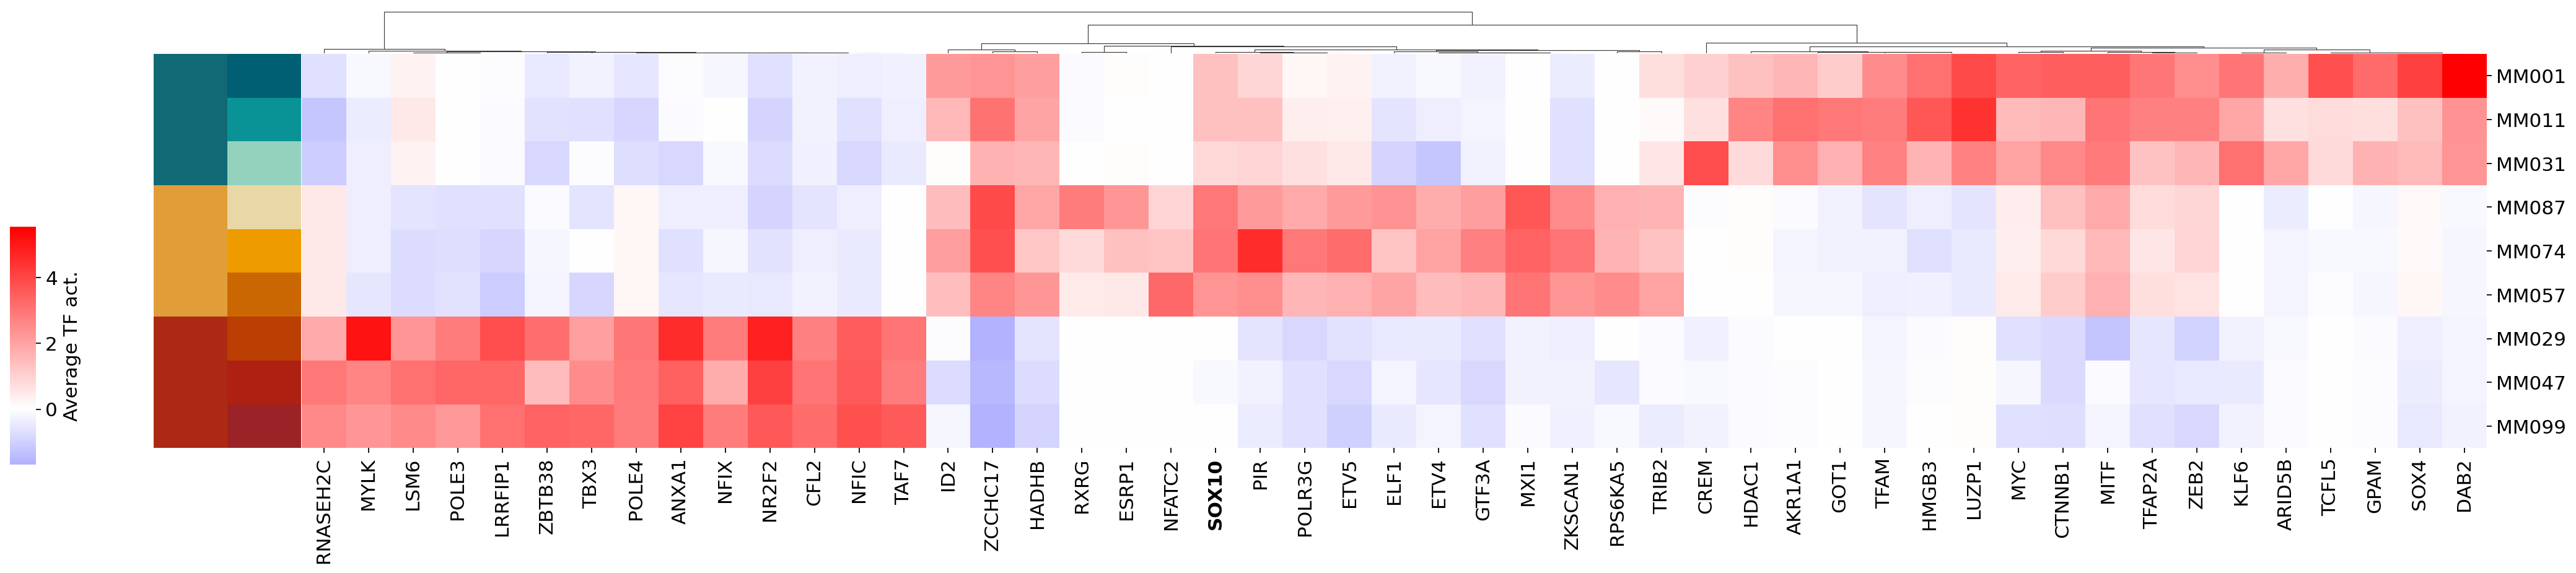

In [50]:
# sns.reset_defaults()
# sns.set(font_scale=1.4)
g = sns.clustermap(df_tf_activity,
               row_cluster=False, 
               cmap='bwr', 
               center=0, 
               figsize=(26,6), 
               xticklabels=True, 
               dendrogram_ratio=(0.05, .1),
               cbar_pos=(0, .2, .01, .4),
               method='average',
               metric='correlation',
               row_colors=[df_tf_activity.index.map(d).map(d_col_state), df_tf_activity.index.map(d_col_line)],
               cbar_kws={'label': 'Average TF act.'},
               # vmax=0.015,
               # vmin=-0.015
              )
# Customize the column tick labels
bold_columns = ['SOX10']
for label in g.ax_heatmap.get_xticklabels():
    if label.get_text() in bold_columns:
        label.set_fontweight('bold')
        
column_order = g.dendrogram_col.reordered_ind
# # Adjust colorbar position
# plt.setp(g.ax_heatmap.collections[0].colorbar.ax.yaxis.get_label(), rotation=90)
# g.cax.set_position([0.05, 0.15, 0.03, 0.6])  # Adjust the position as needed
# plt.show()
# plt.savefig('figures/MMlines_TFs.svg')

In [51]:
df_tf_activity.iloc[:,column_order].to_csv(opt.save_name + 'df_tf_activity.csv')

# TF-Target genes distribution

In [106]:
Wrna = pd.DataFrame(np.matmul(E1.values, E2.values), index=E1.index, columns=E2.columns)
Wrna = Wrna.loc[np.unique(TFs), :]
Wrna = Wrna.loc[:, (Wrna.sum(0)!=0)]
Wrna_strd = (Wrna.abs() - Wrna.abs().mean(0)) / Wrna.abs().std(0)
Wrna_strd_minmax = (Wrna - Wrna.min(1)[:, None]) / (Wrna.max(1) - Wrna.min(1))[:,None]

/tmp/ipykernel_1608578/3342427378.py:5: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  Wrna_strd_minmax = (Wrna - Wrna.min(1)[:, None]) / (Wrna.max(1) - Wrna.min(1))[:,None]


In [116]:
from sklearn.metrics import auc
aucs = []
for tf in Wrna_strd.index:
    aucs.append(auc(np.arange(Wrna_strd.shape[1])/Wrna_strd.shape[1], Wrna_strd_minmax.loc[tf,:].sort_values(ascending=False).values))
df_auc = pd.DataFrame({'auc':aucs}, index=Wrna_strd.index)

In [118]:
df_auc.auc.sort_values(ascending=True)

TP53       0.180392
HADHB      0.187188
RPS6KA5    0.226252
ELF1       0.239342
ZKSCAN1    0.240929
             ...   
MYLK       0.559748
MECOM      0.575226
TCF4       0.585033
SOX9       0.597450
NFE2L3     0.604394
Name: auc, Length: 72, dtype: float64

/staging/leuven/stg_00002/lcb/gpartel/software/anaconda3/envs/DeepSEM/lib/python3.8/site-packages/seaborn/_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


<AxesSubplot: xlabel='auc'>

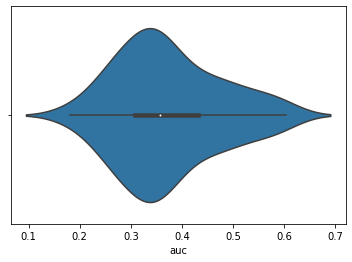

In [119]:
sns.violinplot(df_auc.auc.sort_values(ascending=True))

In [ ]:
df_auc = pd.concat([df_auc.auc.sort_values(ascending=True)[:5], df_auc.auc.sort_values(ascending=False)[:5]])

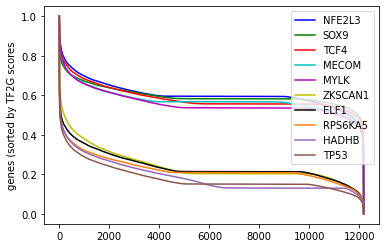

In [112]:
colors = ['b', 'g', 'r', 'c', 'm', 'y', 'k', 'tab:orange', 'tab:purple', 'tab:brown',
          'tab:pink', 'tab:gray', 'tab:olive', 'tab:cyan', 'tab:blue', 'tab:green',
          'tab:red', 'tab:purple', 'tab:orange', 'tab:brown']

for i, tf in enumerate(df_auc.sort_values(ascending=False).index):
    plt.plot(np.arange(Wrna_strd.shape[1]), Wrna_strd_minmax.loc[tf,:].sort_values(ascending=False).values, label=tf, color=colors[i]);
plt.ylabel("abs(Tf2G) scaled scores");
plt.ylabel("genes (sorted by TF2G scores");
plt.legend();

# TF-Target GOs

In [75]:
Wrna = pd.DataFrame(np.matmul(E1.values, E2.values), index=E1.index, columns=E2.columns)
Wrna = Wrna.loc[:, (Wrna.sum(0)!=0)]
Wrna_strd = (Wrna - Wrna.mean(0)) / Wrna.std(0)

In [76]:
df_tf_activity =[]
active_enhancers_l = []
for line in ad.obs.lineState.unique():
    df_tf_activity.append((ad[ad.obs.lineState==line, TFs_idx].X.mean(0)[:,None] * E1))
    
# df_tf_activity = pd.concat(df_tf_activity, axis=1, keys=ad.obs.lineState.unique())    

In [78]:
import dill
scplus_obj = dill.load(open('/lustre1/project/stg_00002/lcb/gpartel/projects/deepSCENIC/data/MM_lines/scplus_obj.pkl', 'rb'))

In [79]:
TF="SOX10"

In [80]:
TF_scplus = scplus_obj.uns['eRegulon_metadata'][scplus_obj.uns['eRegulon_metadata'].TF == TF].sort_values(by='TF2G_importance', ascending=False)
TF_scplus = TF_scplus[TF_scplus.Gene!=TF]

In [83]:
## Print scplus target genes
# [print(x) for x in TF_scplus.Gene.unique()[:500]];

In [84]:
shared_genes = np.intersect1d(Wrna_strd.loc[TF,:].abs().sort_values(ascending=False).dropna()[:500].index.to_list(), TF_scplus.Gene.unique()[:500])
len(shared_genes)

135

In [90]:
## Print scplus shared target genes with deepSCENIC
# [print(x)  for x in TF_scplus.Gene.unique()[:500] if x not in shared_genes]

In [91]:
## Print deepSCENIC unique target genes
# [print(x) for x in Wrna_strd.loc[TF,:].abs().sort_values(ascending=False).dropna()[:500].index if x not in shared_genes]

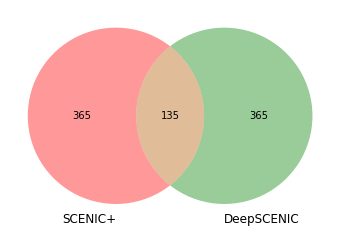

In [92]:
from matplotlib_venn import venn2
venn2(subsets = (500-135, 500-135, 135), set_labels = ('SCENIC+', 'DeepSCENIC'))

In [125]:
# DeepSCENIC non overlapping GOs
TF_gene_GOs = pd.read_csv(TF + '_dsc_GO_nonoverlap.txt', sep='\t')
TF_gene_GOs.Fold_Enrichment = TF_gene_GOs.Fold_Enrichment.astype(float)
df = TF_gene_GOs
df=df[df.FDR<0.01]
df

,GO biological_process_complete,Homo sapiens-REFLIST_(20589),upload_1_(514),expected,over/under,Fold_Enrichment,P-value,FDR
0,cellular process (GO:0009987),14613,359,305.15,+,1.18,3.410000e-09,0.000053
1,Unclassified (UNCLASSIFIED),2878,27,60.10,-,0.45,8.880000e-07,0.003450
2,biological_process (GO:0008150),17714,403,369.90,+,1.09,8.880000e-07,0.004600
3,cellular metabolic process (GO:0044237),5808,170,121.28,+,1.40,5.940000e-07,0.004610
4,vesicle transport along microtubule (GO:0047496),41,8,0.86,+,9.34,6.210000e-06,0.019300
5,axonal transport (GO:0098930),61,9,1.27,+,7.07,1.240000e-05,0.032200
6,relaxation of cardiac muscle (GO:0055119),15,5,0.31,+,15.96,4.210000e-05,0.043600
7,vesicle cytoskeletal trafficking (GO:0099518),65,9,1.36,+,6.63,1.970000e-05,0.043600
8,organic cyclic compound metabolic process (GO:1901360),3244,101,67.74,+,1.49,3.400000e-05,0.044000
9,pigmentation (GO:0043473),106,11,2.21,+,4.97,2.870000e-05,0.044500


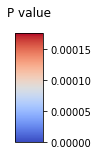

In [121]:
import matplotlib as mpl
from matplotlib import cm

fig,ax = plt.subplots(figsize=(0.5, 2))

cmap = mpl.cm.coolwarm
norm = mpl.colors.Normalize(vmin=df.loc[:,'P-value'].min(), vmax=df.loc[:,'P-value'].max())

mapper = cm.ScalarMappable(norm = norm, cmap= cm.coolwarm)
cbl = mpl.colorbar.ColorbarBase(ax, cmap=cmap, norm=norm, orientation='vertical')
ax.set_title('P value',y=1.1);

Plot top 10 GOs

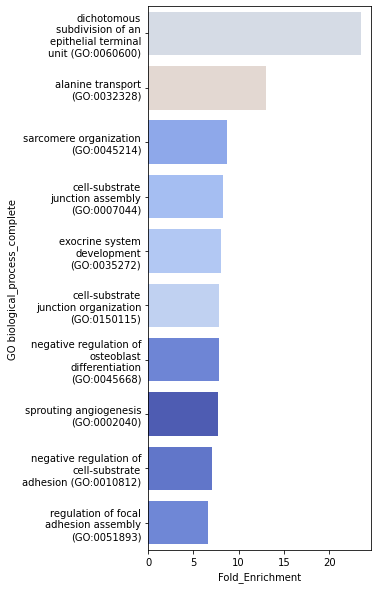

In [123]:
df = df.iloc[:10,:]

import seaborn as sns
import textwrap
plt.figure(figsize=(4,10 ))

ax = sns.barplot(data=df, y='GO biological_process_complete',
                 x='Fold_Enrichment',
                 palette = mapper.to_rgba(df.loc[:,'P-value'].values))

ax.set_yticklabels([textwrap.fill(e,22) for e in df.loc[:,'GO biological_process_complete']])
plt.show()

In [147]:
Wrna_strd = (Wrna - Wrna.mean(0)) / Wrna.std(0)

# Draw GRNs

In [52]:
E1 = pd.read_pickle(opt.save_name + 'E1.pkl')
E2 = pd.read_pickle(opt.save_name + 'E2.pkl')

In [53]:
Wrna = E1 @ E2

In [54]:
from scipy.stats import zscore
Wrna_scaled = Wrna.apply(zscore, axis=1)
E1_scaled = E1.apply(zscore, axis=1)
E2_scaled = E2.apply(zscore, axis=0)

In [86]:
[print(x) for x in Wrna_scaled.loc[['SOX10', 'MITF', 'TFAP2A']].mean().sort_values(ascending=False)[:100].index];

ZCCHC17
ID3
LRPAP1
PSAP
SEC11C
SLC3A2
MTDH
GPNMB
MRPS7
SAT1
SDCBP
CCDC167
SNCA
TIMM17A
MITF
PEPD
ATP1A1
SMDT1
GYPC
PMEL
PRKAR1A
PHACTR1
TBC1D7
ID2
ATP6V1E1
ZEB2
MBP
GRN
AVPI1
CAPN3
CYSTM1
DNAJC3
PSMD11
TFAP2A
AP1S2
SMIM12
MAGED2
MLANA
RGS10
ASAH1
PDIA3
MYH10
YTHDF2
TIMP2
DSTYK
NKAP
SSR1
GLMP
MPC1
UQCRC2
DCT
PIR
FDFT1
HMOX2
SLC7A5
TMEM98
FMN1
RAB27A
BIRC7
STX7
BACE2
RAB1A
BZW2
SOX10
SPTBN1
PGM1
HADHB
VAT1
SDHB
ZFYVE16
ACOT7
MAD1L1
QPCT
INPP4B
FAM210B
SLC25A4
NPM3
GPM6B
TXNL1
TYR
CDK2
HEXA
TTC3
ATP6V0D1
NDUFA9
PDCD6
PAG1
RBBP7
SCD
BHLHE41
TBC1D16
AHCYL1
AIFM1
RUNX3
PRDX3
MPHOSPH8
SGK1
KNOP1
ATP6V1B2
LAMP2


In [10]:
df_tf_activity = pd.read_csv(opt.save_name + 'df_tf_activity.csv', index_col=0)
df_tf_activity

,RNASEH2C,MYLK,LSM6,LRRFIP1,POLE3,ZBTB38,TBX3,POLE4,ANXA1,NFIX,...,MYC,MITF,TFAP2A,ZEB2,ARID5B,KLF6,TCFL5,GPAM,SOX4,DAB2
MM001,-0.685552,-0.147959,0.298341,-0.067683,-0.004521,-0.476373,-0.262217,-0.527499,-0.051375,-0.171313,...,3.351454,3.469371,2.968468,2.443587,1.734936,3.029077,3.794093,3.239275,4.118227,5.544668
MM011,-1.220787,-0.388850,0.515615,-0.099027,-0.002226,-0.622403,-0.685244,-0.867952,-0.110237,-0.022508,...,1.483234,2.990464,2.731465,2.768393,0.661923,1.955835,0.763123,0.733049,1.347244,2.334837
MM031,-1.088379,-0.332742,0.308492,-0.088027,-0.002758,-0.813629,-0.064470,-0.698142,-0.818948,-0.136016,...,2.034386,2.870565,1.317330,1.570108,1.946514,3.105964,0.792398,1.671487,1.481080,2.299766
MM087,0.492522,-0.346909,-0.570339,-0.657927,-0.693069,-0.127876,-0.556438,0.185471,-0.341459,-0.348076,...,0.416787,1.867988,0.754732,0.883039,-0.405643,0.010869,-0.045550,-0.193735,0.170206,-0.155014
MM074,0.515996,-0.371761,-0.762379,-0.868983,-0.713102,-0.185199,-0.030255,0.184854,-0.662916,-0.200018,...,0.401808,1.558670,0.562111,0.926810,-0.231010,0.010050,-0.135650,-0.132138,0.108233,-0.215178
MM057,0.502671,-0.503593,-0.730958,-1.084094,-0.632110,-0.224589,-0.874251,0.212000,-0.501833,-0.443033,...,0.459576,1.711291,0.731375,0.617092,-0.219140,0.014771,-0.058190,-0.196060,0.208667,-0.206364
MM029,1.821364,5.148698,2.312417,3.875722,2.854247,3.121174,2.070011,2.973781,4.560347,2.835507,...,-0.650334,-1.286467,-0.539214,-0.970629,-0.156459,-0.276231,-0.035802,-0.084338,-0.369090,-0.235245
MM047,2.900197,2.683074,3.089150,3.291789,3.338648,1.425246,2.475348,2.870288,3.454907,1.803073,...,-0.214012,-0.109458,-0.535899,-0.478164,-0.108818,-0.455108,-0.026873,-0.050951,-0.390050,-0.238073
MM099,2.575803,2.283157,2.528780,3.091587,2.237946,3.402825,3.289982,2.817149,4.090691,2.813399,...,-0.645398,-0.219077,-0.652568,-0.863525,-0.089446,-0.295922,-0.033238,-0.047716,-0.473144,-0.259597


In [56]:
TF_classes_d = {
    'Melanocytic': [ #These TFs are associated with melanocyte differentiation, pigment production, or regulation of genes related to melanogenesis
        'MITF', 
        'SOX10',
        'TFAP2A',
        'ZEB2',
        'RXRG', 
        'TBX3', # A critical TF for melanocyte development and a repressor of senescence pathways; interacts with MITF to regulate melanocytic differentiation.
        'NR2F2', # Known to regulate pathways involved in pigmentation and melanocytic identity.
        'SOX4', #In some contexts, it can modulate melanocyte differentiation alongside other SOX family members
    ], 
    'Mesenchymal': [ #These TFs contribute to mesenchymal features, epithelial-to-mesenchymal transition (EMT), or AP-1 activity in melanoma
        'CTNNB1',
        'ZEB2',
        'ELF1',
        'ETV4',
        'ETV5',
        'TRIB2',
        'CREM',
        'DAB2',  #Functions as a scaffold protein regulating EMT and mesenchymal features in tumor progression.        
        'PIR',
        'ESRP1', #While primarily involved in epithelial splicing regulation, it also indirectly contributes to EMT processes by influencing splicing of mesenchymal markers
        'KLF6', # Regulates EMT and is involved in promoting invasive and mesenchymal-like phenotypes
        'ZKSCAN1', #Involved in chromatin remodeling and EMT regulation in cancer progression
    ], 
    'Cell Cycle': [ #TFs involved in regulating cell division, DNA replication, or repair pathways
        'MYC', 
        'POLE3',
        'POLE4',
        'HDAC1',
        'NFIC',
        'NFIX',
        'NFATC2',
        'TCFL5',
        'RPS6KA5',
        'TAF7',
        'HMGB3', # Associated with chromatin structure and DNA repair, facilitating tumor growth and proliferation.
        'TFAM', #Mitochondrial transcription factor involved in mitochondrial genome replication and energy metabolism, essential for rapidly dividing cells.
        'ZBTB38', #A zinc-finger protein regulating cell cycle progression and DNA replication through interactions with methylated DNA
        'RNASEH2C', #Part of the RNase H2 complex, critical for DNA replication and genome stability, indirectly affecting proliferation in melanoma.
    ], 
    'Immune-related':[ #TFs involved in immune response or regulation of inflammatory pathways
        'NFATC2',
        'ID2',
        'LUZP1'
    ], 
    'Metabolism and Stress Response': [ #TFs linked to cellular metabolism, stress responses, or related pathways
        'ANXA1',
        'CFL2',
        'HADHB',
        'AKR1A1',
        'GPAM',
        'GOT1', # Primarily a metabolic enzyme,
    ],     
}


In [12]:
for tf in df_tf_activity.columns:
    if tf not in sum(list(TF_classes_d.values()), []):
        print(tf)

MYLK
LSM6
LRRFIP1
ZCCHC17
POLR3G
GTF3A
MXI1
ARID5B


In [13]:
for tf in TF_classes_d['Metabolism and Stress Response']:
    print(tf)

ANXA1
CFL2
HADHB
AKR1A1
GPAM
GOT1


<AxesSubplot: >

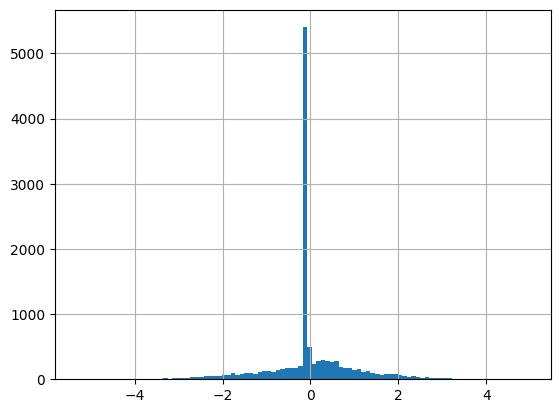

In [14]:
Wrna_scaled.loc['SOX10'].sort_values(ascending=False).hist(bins=100)

In [15]:
# Get TF-TG interactions
TF2TG_d ={}
for tf in df_tf_activity.columns:
# for tf in ['SOX10', 'MITF']:
    TF2TG_d[tf] = Wrna_scaled.loc[tf][Wrna_scaled.loc[tf].abs()>4].index

In [25]:
len([print(y) for y in np.unique(sum([TF2TG_d[x].to_list() for x in ['TFAM', 'LUZP1', 'GOT1', 'AKR1A1', 'HDAC1']],[]))])

ACADM
ACAT2
ACOT9
ACTR3
ACYP1
AIFM1
AKAP12
AKR1A1
ANKRD39
ANP32E
ANXA7
AP1M2
APOO
ATG3
ATP6V1E1
BCAP29
BLOC1S2
BZW2
CAP2
CARD16
CCPG1
CENPF
CISD1
CLTC
COMMD1
COPS7A
COPS8
COX14
CSDE1
DCAF7
DCTN6
DDX39A
DKC1
DNAJC7
DNM1L
DNMT1
DYNC1I2
EBP
EIF2B3
EPB41L2
ERC1
ERGIC2
ERICH1
ESCO1
EXOSC1
EZR
FAM162A
FGFR1OP2
FIP1L1
FNBP1L
FUNDC2
GALE
GDI2
GLRX3
GOT1
HCCS
HDAC1
HMGB3
HMOX1
HMOX2
HNMT
HNRNPF
HSPA4
IAH1
ID3
IDH3G
IER3IP1
ILF2
ILF3
IMMT
ISCA1
KIT
KNOP1
KPNA2
KPNA6
LEPROTL1
LRPAP1
LSM6
LUZP1
MED21
MRPL11
MRPL43
MRPS35
MRPS7
MSI2
MYL12B
NANS
NASP
NCAPD2
NELFCD
NOP16
NOP2
NPM3
OLA1
PAEP
PAGE5
PDIA3
PEF1
PPA1
PQBP1
PRDX1
PRDX3
PRELID3B
PRPF6
PSAP
PSMD11
PTMS
PTP4A2
PTPRU
RAB1A
RAB33A
RAD51C
RDX
REEP5
RNASEH2A
ROCK2
S100A6
SAR1A
SDHB
SEC11C
SERPINE2
SKA2
SRRT
SSR1
STIP1
SYF2
TFAM
THOC2
TIMM17A
TIMP2
TMED2
TMEM230
TRAPPC4
TXLNA
TXNL1
UBXN4
UQCRC2
UROD
USP5
VBP1
VEPH1
WASF2
YTHDF2
ZBTB8OS
ZCCHC17


145

In [13]:
from tqdm import tqdm

TF2R2TG_d = {}
for tf in tqdm(TF2TG_d.keys()):
    TF2R2TG_d[tf] = {}
    for tg in TF2TG_d[tf]:
        # Get enhancers for TF-TG interaction
        TG_enh = E2_scaled.loc[:, tg].sort_values(ascending=False)
        TG_enh = TG_enh[TG_enh>4].index
        TF2TG_enh = E1_scaled.loc[tf, TG_enh]
        #Threshold enh
        TF2TG_enh = TF2TG_enh[TF2TG_enh.abs()>2]
        TF2R2TG_d[tf][tg]=TF2TG_enh.index.to_list()

100%|██████████| 49/49 [00:29<00:00,  1.67it/s]


In [14]:
# Build GRN dataframe
triplets = []
for tf in tqdm(TF2R2TG_d.keys()):
    for tg in TF2R2TG_d[tf].keys():
        if len(TF2R2TG_d[tf][tg])>0:
            for r in TF2R2TG_d[tf][tg]:
                triplets.append([tf,r,tg, E1_scaled.loc[tf,r], E2_scaled.loc[r,tg], Wrna_scaled.loc[tf,tg]])                


100%|██████████| 49/49 [00:00<00:00, 287.61it/s]


In [15]:
GRN_df = pd.DataFrame(triplets, columns=['TF', 'region', 'TG', 'tf2r_score', 'r2tg_score','tf2tg_score'])

In [16]:
MEL_tfs = ['AKR1A1', 'ARID5B','CREM','CTNNB1','DAB2','GOT1','GPAM','HDAC1','HMGB3','KLF6','LUZP1','MITF','MYC','SOX10','SOX4','TCFL5','TFAM','TFAP2A','ZEB2',]
MES_tfs = ['ANXA1','CFL2','LRRFIP1','LSM6','MYLK','NFIC','NFIX','NR2F2','POLE3','POLE4','RNASEH2C','TAF7','TBX3','ZBTB38']
INT_tfs = ['ELF1','ESRP1','ETV4','ETV5','GTF3A','HADHB','ID2','MXI1','NFATC2','PIR','POLR3G','RPS6KA5','RXRG','TRIB2','ZCCHC17','ZKSCAN1']

In [17]:
MES_tg = GRN_df[(GRN_df.TF.isin(MES_tfs)) & (GRN_df.tf2tg_score>0)].TG.unique()
MEL_tg = GRN_df[(GRN_df.TF.isin(MEL_tfs)) & (GRN_df.tf2tg_score>0)].TG.unique()
INT_tg = GRN_df[(GRN_df.TF.isin(INT_tfs)) & (GRN_df.tf2tg_score>0)].TG.unique()

MES_enh = GRN_df[(GRN_df.TF.isin(MES_tfs)) & (GRN_df.tf2tg_score>0)].region.unique()
MEL_enh = GRN_df[(GRN_df.TF.isin(MEL_tfs)) & (GRN_df.tf2tg_score>0)].region.unique()
INT_enh = GRN_df[(GRN_df.TF.isin(INT_tfs)) & (GRN_df.tf2tg_score>0)].region.unique()

In [44]:
edges.interaction_score = edges.interaction_score.abs()

In [27]:
import pandas as pd


# Prepare nodes
tf_nodes = pd.DataFrame({'id': GRN_df['TF'], 'type': 'TF'}).drop_duplicates()
enhancer_nodes = pd.DataFrame({'id': GRN_df['region'], 'type': 'enhancer'}).drop_duplicates()
tg_nodes = pd.DataFrame({'id': GRN_df['TG'], 'type': 'target'}).drop_duplicates()
nodes = pd.concat([tf_nodes, enhancer_nodes, tg_nodes]).drop_duplicates()

# Prepare edges
edges = pd.concat([
    GRN_df[['TF', 'region', 'tf2r_score']].rename(columns={'TF': 'source', 'region': 'target', 'tf2r_score': 'interaction_score'}),
    GRN_df[['region', 'TG', 'r2tg_score']].rename(columns={'region': 'source', 'TG': 'target', 'r2tg_score': 'interaction_score'}),
])

# # Save to CSV for Cytoscape import
# nodes.to_csv("nodes.csv", index=False)
# edges.to_csv("edges.csv", index=False)


In [10]:
#.loc[TF2r_d[tf][0]][E2.loc[TF2r_d[tf][0]]>0]

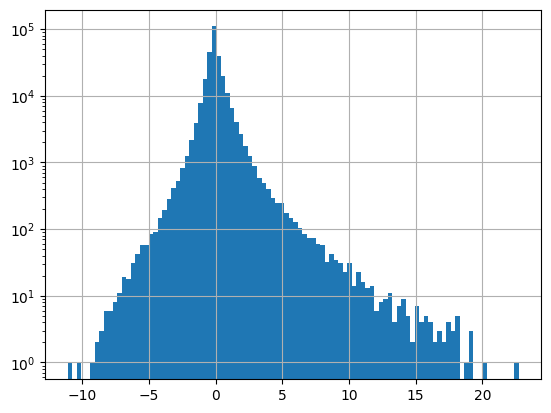

In [30]:
E1_scaled.loc['TFAP2A'].hist(bins=100)
plt.yscale('log')

In [59]:
TF2r_d ={}
# for tf in df_tf_activity.columns:
for tf in ['SOX10', 'MITF']:
    TF2r_d[tf] = E1_scaled.loc[tf][E1_scaled.loc[tf].abs()>10].index

In [60]:
TF2r_d['SOX10']

Index(['chr10:103727415-103727915', 'chr10:124724458-124724958',
       'chr10:71981283-71981783', 'chr10:96416618-96417118',
       'chr11:105357257-105357757', 'chr11:19676487-19676987',
       'chr11:68266315-68266815', 'chr11:70302283-70302783',
       'chr11:73652249-73652749', 'chr12:120221019-120221519',
       ...
       'chr8:127944977-127945477', 'chr8:129316084-129316584',
       'chr8:129633260-129633760', 'chr8:141026690-141027190',
       'chr8:22666726-22667226', 'chr8:61823314-61823814',
       'chr8:75076375-75076875', 'chr8:86416044-86416544',
       'chr9:112041681-112042181', 'chr9:134602522-134603022'],
      dtype='object', length=118)

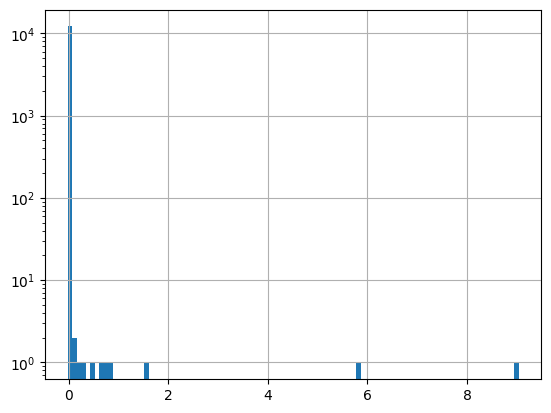

In [61]:
E2_scaled.loc['chr10:103727415-103727915'].hist(bins=100)
plt.yscale('log')

In [63]:
from tqdm import tqdm
r2g_d = {}
for tf in tqdm(df_tf_activity.columns):
# for tf in ['SOX10', 'MITF']:    
    for r in TF2r_d[tf]:
        tg = E2_scaled.loc[r][E2_scaled.loc[r]>2]
        if len(tg)>0:
            r2g_d[r] = tg.index

In [64]:
tf_targets = {}
for tf in TF2r_d.keys():
    targets = []
    for r in TF2r_d[tf]:
        if r in  r2g_d.keys():
            targets.extend(r2g_d[r].to_list())
    tf_targets[tf] = targets

In [65]:
# Create edge list
edges = []

# TF -> Region edges
for tf, regions in TF2r_d.items():
    for region in regions:
        edges.append({"source": tf, "target": region, "interaction": "TF-to-region"})

# Region -> Gene edges
for region, genes in r2g_d.items():
    for gene in genes:
        edges.append({"source": region, "target": gene, "interaction": "region-to-gene"})

# Save edges to CSV
edges_df = pd.DataFrame(edges)
edges_df.to_csv("edges.csv", index=False)

# Create node list
nodes = set(TF2r_d.keys()) | set(r2g_d.keys()) | {gene for genes in r2g_d.values() for gene in genes}
node_types = []

for node in nodes:
    if node in TF2r_d.keys():
        node_types.append({"id": node, "type": "TF"})
    elif node in r2g_d.keys():
        node_types.append({"id": node, "type": "region"})
    else:
        node_types.append({"id": node, "type": "gene"})

# Save nodes to CSV
nodes_df = pd.DataFrame(node_types)
nodes_df.to_csv("nodes.csv", index=False)

In [59]:
DATA_PATH = '/lustre1/project/stg_00002/lcb/gpartel/projects/deepSCENIC/data/MM_lines/'
GRN_edges = pd.read_csv(DATA_PATH + 'MMlines_grn_edges.csv')
GRN_nodes = pd.read_csv(DATA_PATH + 'MMLines_grn_nodes.csv')

In [31]:
cells_metadata = pd.read_csv(DATA_PATH + '/cells_metadata.csv', index_col=0)

ad_rna = sc.read(opt.data_rna_file)
ad_rna.obs[cells_metadata.columns] = cells_metadata.loc[ad_rna.obs.index,:].values

ad_atac = sc.read(opt.data_atac_file)
ad_atac.obs[cells_metadata.columns] = cells_metadata.loc[ad_atac.obs.index,:].values


In [32]:
sc.pp.scale(ad_rna)
sc.pp.scale(ad_atac)

In [36]:
enh_atac = ad_atac.to_df().loc[:, GRN_nodes[GRN_nodes.type=='enhancer'].name].groupby(ad_atac.obs.lineState).mean().T

In [37]:
nodes_exp = ad_rna.to_df().loc[:, GRN_nodes[GRN_nodes.type!='enhancer'].name].groupby(ad_rna.obs.lineState).mean().T

In [61]:
for line in ad_rna.obs.lineState.unique():
    GRN_nodes[line + '_act'] = 0

GRN_nodes=GRN_nodes.set_index('shared name')
for line in ad_rna.obs.lineState.unique():
    GRN_nodes.loc[nodes_exp.index, line + '_act'] = nodes_exp.loc[:, line].values
    GRN_nodes.loc[enh_atac.index, line + '_act'] = enh_atac.loc[:, line].values

In [64]:
GRN_nodes = GRN_nodes.reset_index()

In [66]:
GRN_nodes.to_csv(opt.save_name + 'MMlines_grn_nodes.csv')

In [67]:
opt.save_name

'/lustre1/project/stg_00002/lcb/gpartel/projects/deepSCENIC/results/MM_lines/'